# 💊 HealthTrack — Personal Health Appointment & Medication Tracker
### Capstone Project | Python Training Program
**Author:** Anusha Banoth

---

### Problem Statement
Managing personal health is something most people struggle with day to day. Missed medication doses, forgotten follow-up appointments, and no visibility into personal health trends are very common problems.

**HealthTrack** solves this by giving users a unified notebook where they can:
- Load and explore their health data
- Analyze appointment and medication trends
- Visualize patterns through charts and graphs
- Predict medication adherence using Machine Learning
- Interact with a Gen AI health assistant

---


## 📦 Step 1 — Importing Necessary Libraries

In [2]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# To show figures inline in the notebook
%matplotlib inline

# Set default plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


## 📂 Step 2 — Loading the Data

In [3]:
# Loading the appointments data
appointments = pd.read_csv("appointments.csv", parse_dates=["Date"])
print("Appointments Data - First 5 rows:")
appointments.head()

Appointments Data - First 5 rows:


,Date,Doctor,Specialty,Reason,Notes,Cost
0,2024-01-01,Dr. Mark Thompson,Dentistry,Gum check,Prescribed medication for 2 weeks,175.03
1,2024-01-02,Dr. Lisa Chen,Neurology,Dizziness,Lab tests ordered,291.38
2,2024-01-04,Dr. Priya Nair,Dermatology,Eczema follow-up,Advised lifestyle changes,156.12
3,2024-01-06,Dr. James Patel,Cardiology,Cholesterol check,Referred to specialist,353.72
4,2024-01-07,Dr. Rachel Adams,Endocrinology,Hormone levels,Follow-up in 4 weeks,220.69


In [4]:
# Loading the medications data
medications = pd.read_csv("medications.csv", parse_dates=["Date"])
print("Medications Data - First 5 rows:")
medications.head()

Medications Data - First 5 rows:


,Date,Medication,Dosage,Scheduled_Time,Taken,Side_Effects
0,2024-01-03,Lisinopril,10mg,Morning,Yes,NaN
1,2024-01-03,Atorvastatin,20mg,Afternoon,Yes,NaN
2,2024-01-08,Omeprazole,20mg,Afternoon,Yes,Mild nausea
3,2024-01-09,Omeprazole,20mg,Afternoon,Yes,Fatigue
4,2024-01-11,Metformin,500mg,Afternoon,Yes,NaN


## 🔍 Step 3 — Data Overview & Basic Info

In [5]:
# Shape of the datasets
print("Appointments Shape:", appointments.shape)
print("Medications Shape :", medications.shape)

Appointments Shape: (220, 6)
Medications Shape : (250, 6)


In [6]:
# Appointments - column info
print("Appointments - Column Info:")
appointments.info()

Appointments - Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       220 non-null    datetime64[ns]
 1   Doctor     220 non-null    object        
 2   Specialty  220 non-null    object        
 3   Reason     220 non-null    object        
 4   Notes      220 non-null    object        
 5   Cost       220 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 10.4+ KB


In [8]:
# Medications - column info
print("Medications - Column Info:")
medications.info()

Medications - Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            250 non-null    datetime64[ns]
 1   Medication      250 non-null    object        
 2   Dosage          250 non-null    object        
 3   Scheduled_Time  250 non-null    object        
 4   Taken           250 non-null    object        
 5   Side_Effects    83 non-null     object        
dtypes: datetime64[ns](1), object(5)
memory usage: 11.8+ KB


In [7]:
# Check for missing values
print("Missing values in Appointments:")
print(appointments.isnull().sum())
print()
print("Missing values in Medications:")
print(medications.isnull().sum())

Missing values in Appointments:
Date         0
Doctor       0
Specialty    0
Reason       0
Notes        0
Cost         0
dtype: int64

Missing values in Medications:
Date                0
Medication          0
Dosage              0
Scheduled_Time      0
Taken               0
Side_Effects      167
dtype: int64


In [9]:
# Basic statistics for appointments cost
print("Appointments - Cost Statistics:")
appointments["Cost"].describe()

Appointments - Cost Statistics:


count    220.000000
mean     236.248591
std       81.653452
min       82.340000
25%      181.525000
50%      233.980000
75%      284.627500
max      488.430000
Name: Cost, dtype: float64

## 🧹 Step 4 — Data Cleaning & Feature Engineering

In [10]:
# Adding helper columns to appointments
appointments["Month"] = appointments["Date"].dt.month
appointments["Month_Name"] = appointments["Date"].dt.strftime("%B")
appointments["Year"] = appointments["Date"].dt.year
appointments["Day_Of_Week"] = appointments["Date"].dt.day_name()

print("Appointments after adding helper columns:")
appointments[["Date", "Month", "Month_Name", "Year", "Day_Of_Week"]].head()

Appointments after adding helper columns:


,Date,Month,Month_Name,Year,Day_Of_Week
0,2024-01-01,1,January,2024,Monday
1,2024-01-02,1,January,2024,Tuesday
2,2024-01-04,1,January,2024,Thursday
3,2024-01-06,1,January,2024,Saturday
4,2024-01-07,1,January,2024,Sunday


In [11]:
# Adding helper columns to medications
medications["Month"] = medications["Date"].dt.month
medications["Month_Name"] = medications["Date"].dt.strftime("%B")
medications["Year"] = medications["Date"].dt.year
medications["Day_Of_Week"] = medications["Date"].dt.day_name()
medications["Day_Of_Week_Num"] = medications["Date"].dt.dayofweek

# Binary column for ML model: 1 = Taken, 0 = Missed
medications["Taken_Binary"] = medications["Taken"].apply(lambda x: 1 if x == "Yes" else 0)

print("Medications after adding helper columns:")
medications[["Date", "Medication", "Scheduled_Time", "Taken", "Taken_Binary"]].head()

Medications after adding helper columns:


,Date,Medication,Scheduled_Time,Taken,Taken_Binary
0,2024-01-03,Lisinopril,Morning,Yes,1
1,2024-01-03,Atorvastatin,Afternoon,Yes,1
2,2024-01-08,Omeprazole,Afternoon,Yes,1
3,2024-01-09,Omeprazole,Afternoon,Yes,1
4,2024-01-11,Metformin,Afternoon,Yes,1


In [29]:
# Summary metrics
total_appointments = len(appointments)
total_medications = len(medications)
taken_count = medications["Taken_Binary"].sum()
adherence_rate = round((taken_count / total_medications) * 100, 1)
total_spend = round(appointments["Cost"].sum(), 2)
missed_doses = total_medications - taken_count

print("=" * 40)
print("        HEALTH SUMMARY DASHBOARD")
print("=" * 40)
print(f"  Total Appointments  : {total_appointments}")
print(f"  Total Medication Logs: {total_medications}")
print(f"  Overall Adherence   : {adherence_rate}%")
print(f"  Total Missed Doses  : {int(missed_doses)}")
print(f"  Total Health Spend  : ${total_spend:,.2f}")
print("=" * 40)

        HEALTH SUMMARY DASHBOARD
  Total Appointments  : 220
  Total Medication Logs: 250
  Overall Adherence   : 72.4%
  Total Missed Doses  : 69
  Total Health Spend  : $51,974.69


## 📅 Step 5 — Appointments Analysis & Visualizations

In [12]:
# Looking at last few rows of appointments
appointments.tail()

,Date,Doctor,Specialty,Reason,Notes,Cost,Month,Month_Name,Year,Day_Of_Week
215,2024-12-25,Dr. James Patel,Cardiology,Heart palpitations,Prescribed medication for 2 weeks,371.72,12,December,2024,Wednesday
216,2024-12-27,Dr. Lisa Chen,Neurology,Sleep disorder,Follow-up in 4 weeks,323.73,12,December,2024,Friday
217,2024-12-28,Dr. Sarah Mitchell,General Practitioner,Fever and cold,Follow-up in 4 weeks,143.38,12,December,2024,Saturday
218,2024-12-29,Dr. Priya Nair,Dermatology,Mole check,X-ray scheduled,121.78,12,December,2024,Sunday
219,2024-12-31,Dr. Lisa Chen,Neurology,Headache follow-up,Referred to specialist,260.45,12,December,2024,Tuesday


In [13]:
# Appointments grouped by month
appt_by_month = (
    appointments.groupby(["Month", "Month_Name"])
    .size()
    .reset_index(name="Count")
    .sort_values("Month")
)
appt_by_month

,Month,Month_Name,Count
0,1,January,16
1,2,February,12
2,3,March,17
3,4,April,15
4,5,May,21
5,6,June,17
6,7,July,26
7,8,August,18
8,9,September,14
9,10,October,26


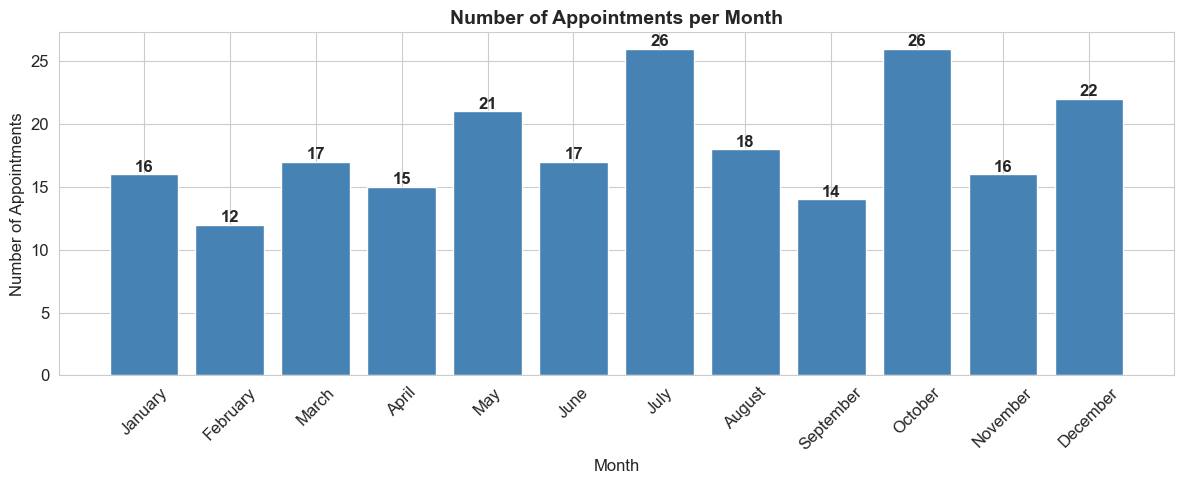

In [14]:
# Plotting appointments per month
plt.figure(figsize=(12, 5))
plt.bar(appt_by_month["Month_Name"], appt_by_month["Count"], color="steelblue", edgecolor="white")
plt.title("Number of Appointments per Month", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=45)
for i, v in enumerate(appt_by_month["Count"]):
    plt.text(i, v + 0.2, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
# Appointments by specialty
appt_by_specialty = (
    appointments.groupby("Specialty")
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)
appt_by_specialty

,Specialty,Count
0,Cardiology,33
2,Dermatology,33
3,Endocrinology,30
5,General Practitioner,27
6,Neurology,26
4,Gastroenterology,25
7,Orthopedics,24
1,Dentistry,22


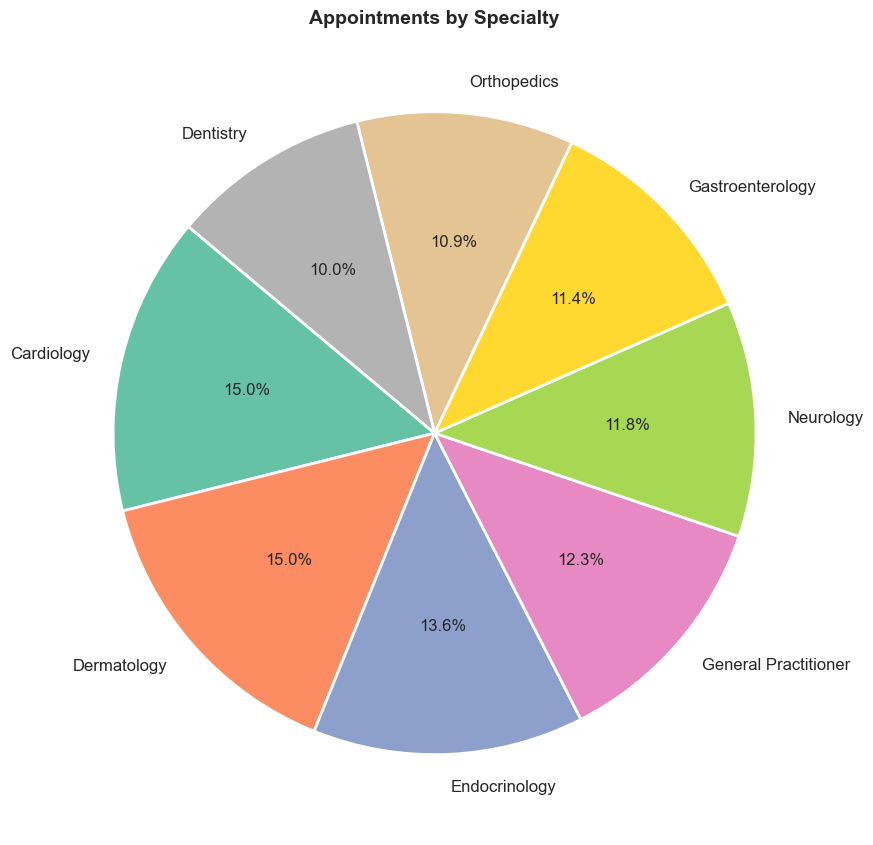

In [16]:
# Plotting appointments by specialty - Pie Chart
plt.figure(figsize=(9, 9))
colors = sns.color_palette("Set2", len(appt_by_specialty))
plt.pie(
    appt_by_specialty["Count"],
    labels=appt_by_specialty["Specialty"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
plt.title("Appointments by Specialty", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\Anusha\AppData\Local\Temp\ipykernel_21316\954323323.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=appt_by_specialty, x="Specialty", y="Count", palette="Blues_d")


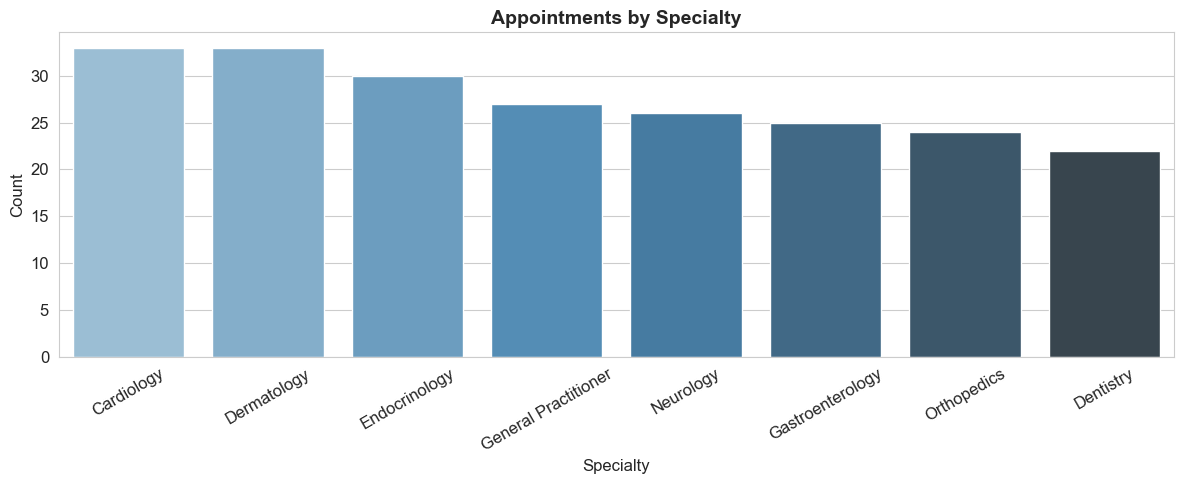

In [17]:
# Plotting appointments by specialty - Bar Chart
plt.figure(figsize=(12, 5))
sns.barplot(data=appt_by_specialty, x="Specialty", y="Count", palette="Blues_d")
plt.title("Appointments by Specialty", fontsize=14, fontweight="bold")
plt.xlabel("Specialty")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

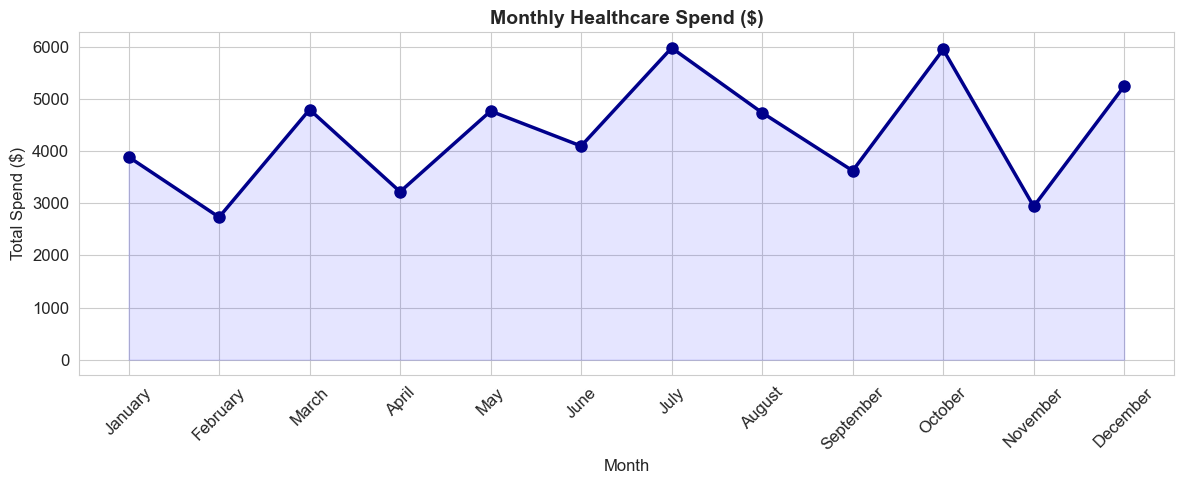

In [18]:
# Monthly healthcare spend
monthly_spend = (
    appointments.groupby(["Month", "Month_Name"])["Cost"]
    .sum()
    .reset_index(name="Total_Cost")
    .sort_values("Month")
)

# Plotting monthly spend - Line Chart
plt.figure(figsize=(12, 5))
plt.plot(monthly_spend["Month_Name"], monthly_spend["Total_Cost"],
         marker="o", linewidth=2.5, color="darkblue", markersize=8)
plt.fill_between(range(len(monthly_spend)), monthly_spend["Total_Cost"], alpha=0.1, color="blue")
plt.title("Monthly Healthcare Spend ($)", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Spend ($)")
plt.xticks(range(len(monthly_spend)), monthly_spend["Month_Name"], rotation=45)
plt.tight_layout()
plt.show()

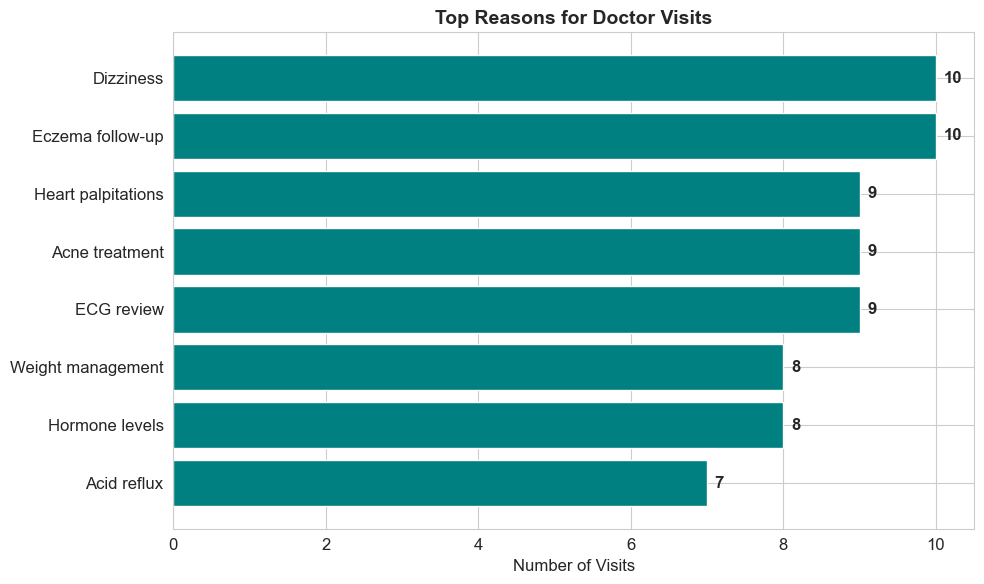

In [19]:
# Top reasons for appointments
top_reasons = (
    appointments.groupby("Reason")
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
    .head(8)
)

# Plotting top reasons - Horizontal Bar Chart
plt.figure(figsize=(10, 6))
plt.barh(top_reasons["Reason"], top_reasons["Count"], color="teal")
plt.title("Top Reasons for Doctor Visits", fontsize=14, fontweight="bold")
plt.xlabel("Number of Visits")
plt.gca().invert_yaxis()
for i, v in enumerate(top_reasons["Count"]):
    plt.text(v + 0.1, i, str(v), va="center", fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\Anusha\AppData\Local\Temp\ipykernel_21316\4223157848.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=appt_by_doctor, x="Doctor", y="Count", palette="Purples_d")


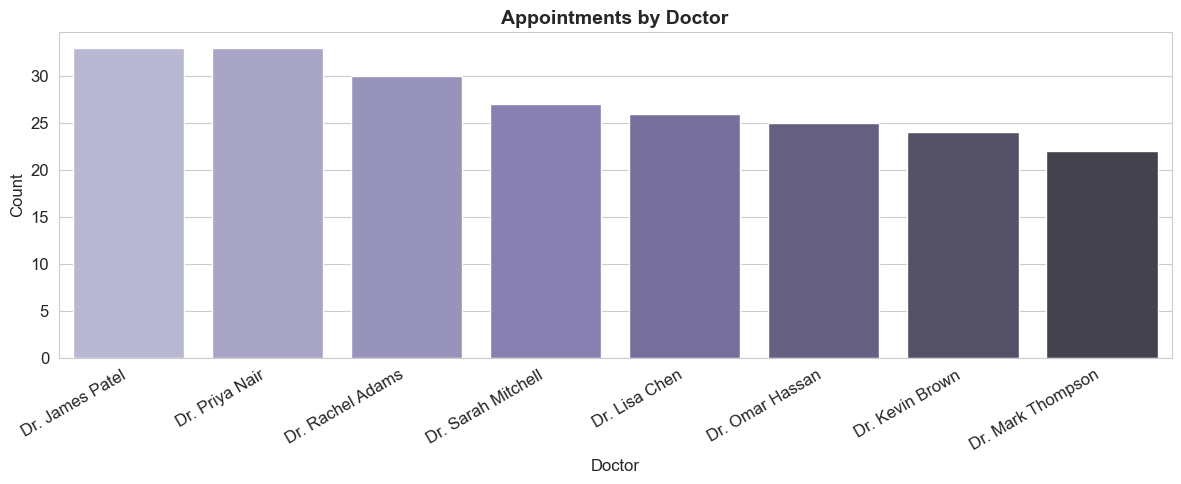

In [20]:
# Appointments by doctor
appt_by_doctor = (
    appointments.groupby("Doctor")
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

# Plotting appointments by doctor
plt.figure(figsize=(12, 5))
sns.barplot(data=appt_by_doctor, x="Doctor", y="Count", palette="Purples_d")
plt.title("Appointments by Doctor", fontsize=14, fontweight="bold")
plt.xlabel("Doctor")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 💊 Step 6 — Medication & Adherence Analysis & Visualizations

In [21]:
# Adherence by month
adh_by_month = (
    medications.groupby(["Month", "Month_Name"])["Taken_Binary"]
    .agg(["sum", "count"])
    .reset_index()
)
adh_by_month.columns = ["Month", "Month_Name", "Taken", "Total"]
adh_by_month["Adherence_Rate"] = round((adh_by_month["Taken"] / adh_by_month["Total"]) * 100, 1)
adh_by_month = adh_by_month.sort_values("Month")
adh_by_month

,Month,Month_Name,Taken,Total,Adherence_Rate
0,1,January,14,19,73.7
1,2,February,20,26,76.9
2,3,March,20,28,71.4
3,4,April,10,15,66.7
4,5,May,8,11,72.7
5,6,June,18,21,85.7
6,7,July,11,17,64.7
7,8,August,24,30,80.0
8,9,September,17,27,63.0
9,10,October,16,24,66.7


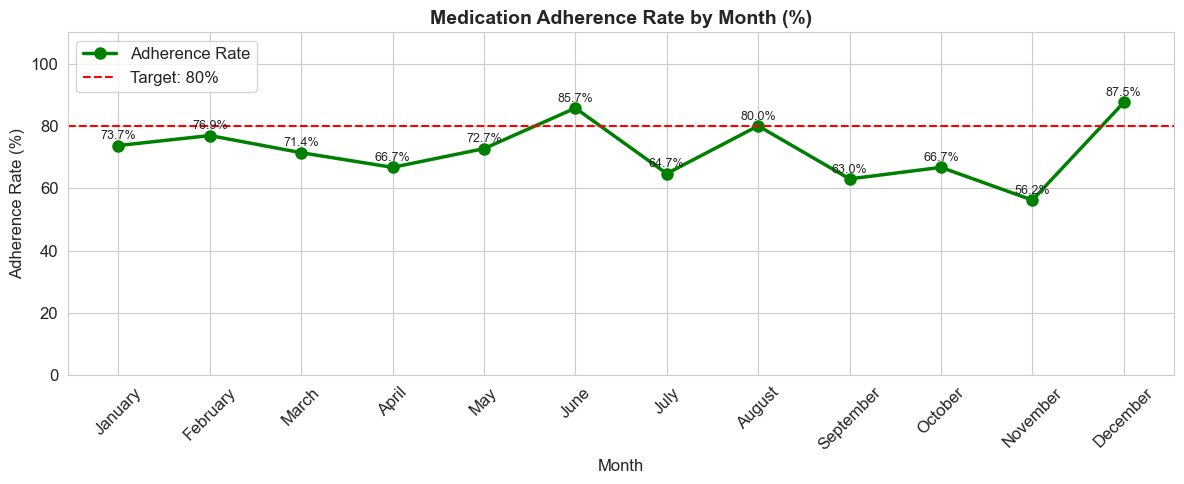

In [22]:
# Plotting adherence rate by month - Line Chart
plt.figure(figsize=(12, 5))
plt.plot(adh_by_month["Month_Name"], adh_by_month["Adherence_Rate"],
         marker="o", linewidth=2.5, color="green", markersize=8, label="Adherence Rate")
plt.axhline(y=80, color="red", linestyle="--", linewidth=1.5, label="Target: 80%")
plt.title("Medication Adherence Rate by Month (%)", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Adherence Rate (%)")
plt.xticks(rotation=45)
plt.ylim(0, 110)
plt.legend()
for i, row in adh_by_month.iterrows():
    idx = list(adh_by_month["Month_Name"]).index(row["Month_Name"])
    plt.text(idx, row["Adherence_Rate"] + 2, f"{row['Adherence_Rate']}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

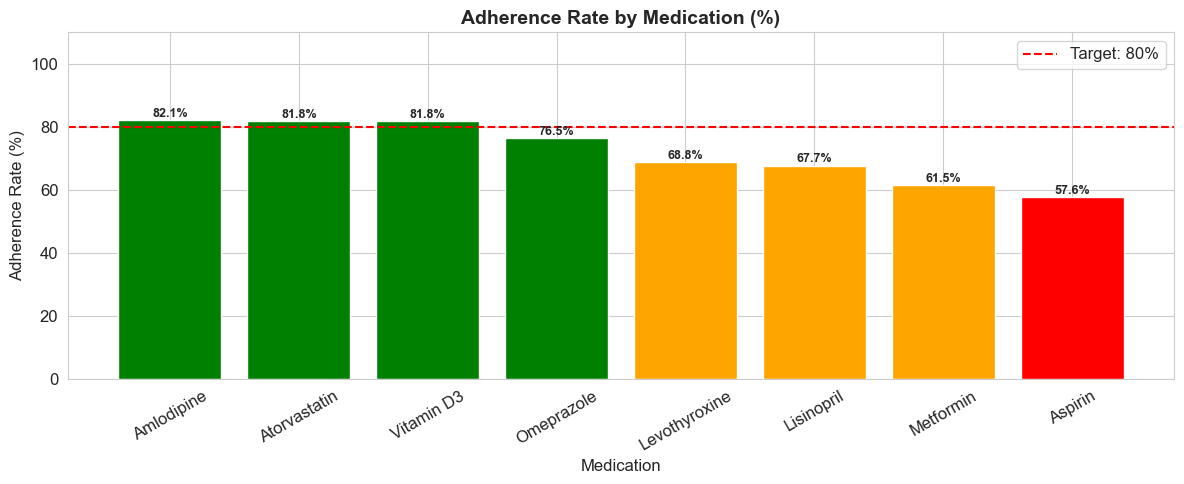

In [23]:
# Adherence by medication
adh_by_med = (
    medications.groupby("Medication")["Taken_Binary"]
    .agg(["sum", "count"])
    .reset_index()
)
adh_by_med.columns = ["Medication", "Taken", "Total"]
adh_by_med["Adherence_Rate"] = round((adh_by_med["Taken"] / adh_by_med["Total"]) * 100, 1)
adh_by_med = adh_by_med.sort_values("Adherence_Rate", ascending=False)

# Plotting adherence by medication
plt.figure(figsize=(12, 5))
colors = ["green" if x >= 75 else "orange" if x >= 60 else "red" for x in adh_by_med["Adherence_Rate"]]
plt.bar(adh_by_med["Medication"], adh_by_med["Adherence_Rate"], color=colors, edgecolor="white")
plt.axhline(y=80, color="red", linestyle="--", linewidth=1.5, label="Target: 80%")
plt.title("Adherence Rate by Medication (%)", fontsize=14, fontweight="bold")
plt.xlabel("Medication")
plt.ylabel("Adherence Rate (%)")
plt.xticks(rotation=30)
plt.ylim(0, 110)
plt.legend()
for i, v in enumerate(adh_by_med["Adherence_Rate"]):
    plt.text(i, v + 1, f"{v}%", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

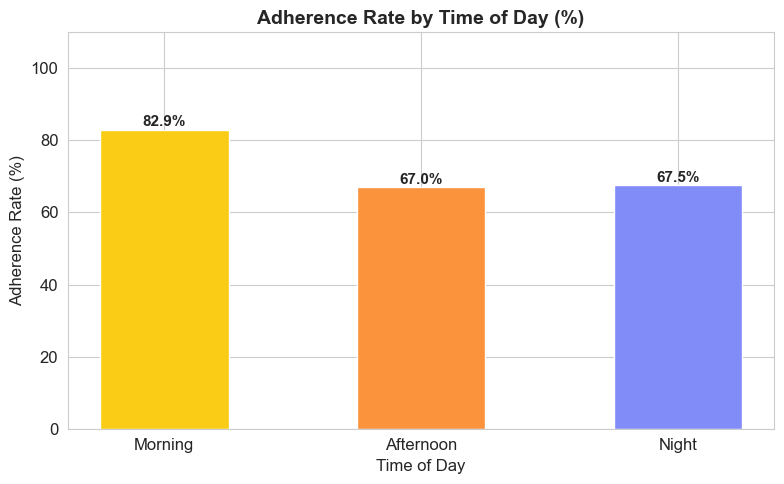

In [24]:
# Adherence by time of day
adh_by_time = (
    medications.groupby("Scheduled_Time")["Taken_Binary"]
    .agg(["sum", "count"])
    .reset_index()
)
adh_by_time.columns = ["Scheduled_Time", "Taken", "Total"]
adh_by_time["Adherence_Rate"] = round((adh_by_time["Taken"] / adh_by_time["Total"]) * 100, 1)
time_order = {"Morning": 0, "Afternoon": 1, "Night": 2}
adh_by_time["Order"] = adh_by_time["Scheduled_Time"].map(time_order)
adh_by_time = adh_by_time.sort_values("Order")

# Plotting adherence by time of day
plt.figure(figsize=(8, 5))
colors = ["#facc15", "#fb923c", "#818cf8"]
plt.bar(adh_by_time["Scheduled_Time"], adh_by_time["Adherence_Rate"], color=colors, edgecolor="white", width=0.5)
plt.title("Adherence Rate by Time of Day (%)", fontsize=14, fontweight="bold")
plt.xlabel("Time of Day")
plt.ylabel("Adherence Rate (%)")
plt.ylim(0, 110)
for i, v in enumerate(adh_by_time["Adherence_Rate"]):
    plt.text(i, v + 1, f"{v}%", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

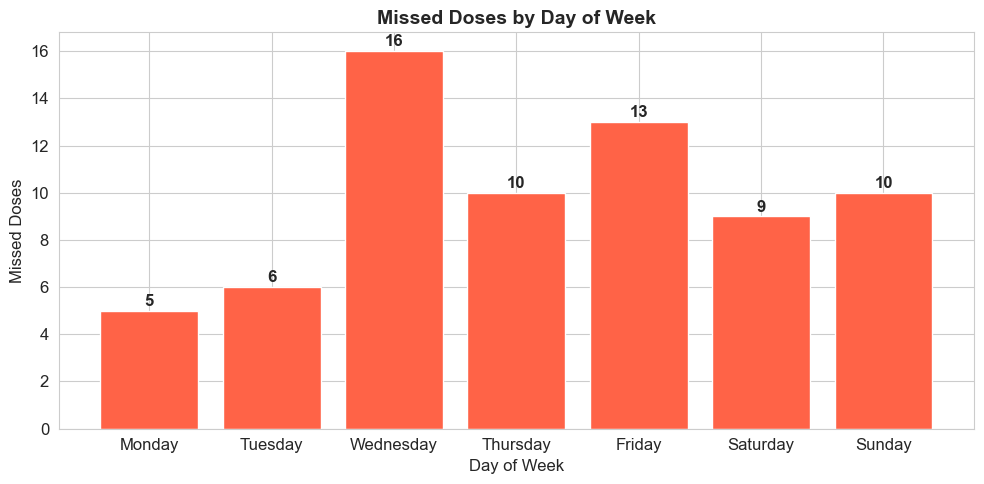

In [25]:
# Missed doses by day of week
missed = medications[medications["Taken"] == "No"]
missed_by_day = (
    missed.groupby(["Day_Of_Week_Num", "Day_Of_Week"])
    .size()
    .reset_index(name="Missed_Count")
    .sort_values("Day_Of_Week_Num")
)

# Plotting missed doses by day of week
plt.figure(figsize=(10, 5))
plt.bar(missed_by_day["Day_Of_Week"], missed_by_day["Missed_Count"], color="tomato", edgecolor="white")
plt.title("Missed Doses by Day of Week", fontsize=14, fontweight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Missed Doses")
for i, v in enumerate(missed_by_day["Missed_Count"]):
    plt.text(i, v + 0.2, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\Anusha\AppData\Local\Temp\ipykernel_21316\2563754898.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=se_summary, x="Side_Effects", y="Count", palette="Oranges_d")


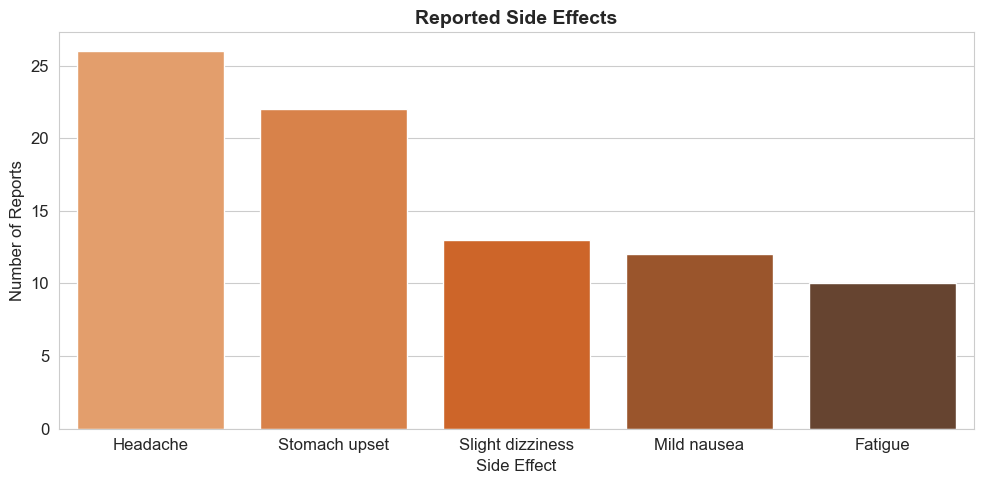

In [26]:
# Side effects reported
side_effects = medications[medications["Side_Effects"] != "None"]
se_summary = (
    side_effects.groupby("Side_Effects")
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

# Plotting side effects
plt.figure(figsize=(10, 5))
sns.barplot(data=se_summary, x="Side_Effects", y="Count", palette="Oranges_d")
plt.title("Reported Side Effects", fontsize=14, fontweight="bold")
plt.xlabel("Side Effect")
plt.ylabel("Number of Reports")
plt.tight_layout()
plt.show()

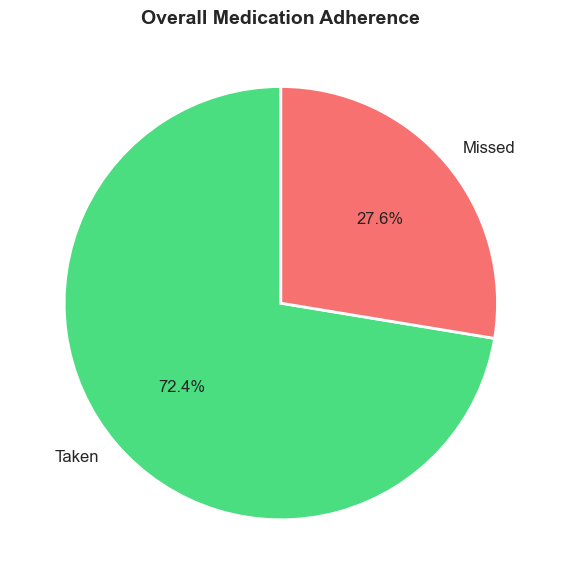

In [27]:
# Taken vs Missed - Overall comparison
taken_vs_missed = medications["Taken"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    taken_vs_missed,
    labels=["Taken", "Missed"],
    autopct="%1.1f%%",
    colors=["#4ade80", "#f87171"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
plt.title("Overall Medication Adherence", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 🔥 Step 7 — Correlation Heatmap

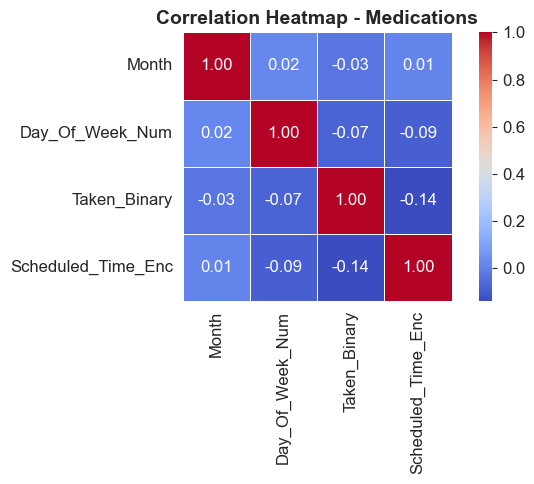

In [28]:
# Correlation heatmap on medications numeric columns
med_numeric = medications[["Month", "Day_Of_Week_Num", "Taken_Binary"]].copy()
# Encode Scheduled_Time as numbers
time_map = {"Morning": 0, "Afternoon": 1, "Night": 2}
med_numeric["Scheduled_Time_Enc"] = medications["Scheduled_Time"].map(time_map)

plt.figure(figsize=(7, 5))
sns.heatmap(
    med_numeric.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)
plt.title("Correlation Heatmap - Medications", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## ✅ Summary

| Metric | Value |
|---|---|
| Total Appointments | 220 |
| Total Medication Logs | 250 |
| Overall Adherence Rate | 72.4% |
| Total Missed Doses | 69 |
| Total Healthcare Spend | $51,974.69 |

### Key Findings
- **Cardiology and Dermatology** had the highest number of visits
- **Morning doses** are taken most consistently (82.9% adherence)
- **Night doses** are missed the most — a clear pattern for the ML model to learn
- **Wednesday** sees the highest number of missed doses across the week
- **Metformin and Lisinopril** show lower adherence than Vitamin D3


